### **SMOTE (Synthetic Minority Oversampling Technique)**

SMOTE is a technique used in machine learning to address imbalanced datasets where the **minority class has significantly fewer instancees** than the majority class. **SMOTE** involues generating synthetic instances of the minority class by **interpolating** between existing instances.

In [1]:
from sklearn.datasets import make_classification

In [171]:
X,y = make_classification(
                    n_samples=100,
                    n_redundant=0,
                    n_features=2,
                    n_clusters_per_class=1,
                    weights=[.90],
                    random_state=42
                )

In [172]:
X.shape,y.shape

((100, 2), (100,))

In [173]:
import pandas as pd

In [174]:
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])

final_df = pd.concat([df1,df2],axis=1)

final_df.head()

,f1,f2,target
0,1.228312,-0.757178,0
1,0.698409,-1.380295,0
2,1.559973,-0.397982,0
3,0.573579,-1.352979,0
4,0.585900,-1.337457,0


In [175]:
import matplotlib.pyplot as plt

In [176]:
final_df['target'].value_counts()

target
0    91
1     9
Name: count, dtype: int64

`Distribution before applying SMOTE`

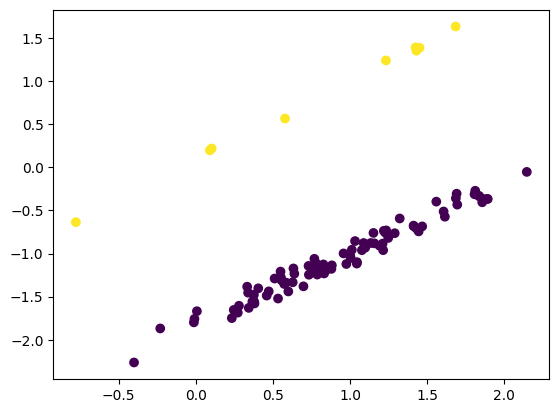

In [177]:
plt.scatter(final_df['f1'],final_df['f2'],c = final_df['target'])
plt.show()

In [ ]:
# !pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)

   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---

In [178]:
from imblearn.over_sampling import SMOTE

In [179]:
# transforming the dataset using SMOTE
oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [180]:
X.shape,y.shape

((182, 2), (182,))

In [181]:
df1_oversamp  = pd.DataFrame(X,columns=['f1','f2'])
df2_oversamp  = pd.DataFrame(y,columns=['target'])

# concatinating 
oversample_df = pd.concat([df1_oversamp,df2_oversamp],axis=1)


In [182]:
oversample_df

,f1,f2,target
0,1.228312,-0.757178,0
1,0.698409,-1.380295,0
2,1.559973,-0.397982,0
3,0.573579,-1.352979,0
4,0.585900,-1.337457,0
...,...,...,...
177,0.098141,0.208855,1
178,-0.770725,-0.629842,1
179,0.914844,0.951488,1
180,1.368921,1.334626,1


In [183]:
oversample_df.shape

(182, 3)

`Distribution after applying SMOTE`

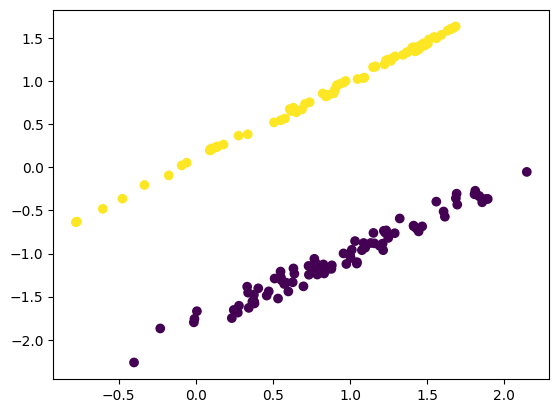

In [184]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c = oversample_df['target'])
plt.show()

#### **Applying SMOTE on Real Data**

In [216]:
df = pd.read_csv('score_100.csv')

In [217]:
df.head()

,runs,form,score_100
0,28,6,0
1,18,9,0
2,9,2,0
3,55,1,0
4,17,4,0


In [218]:
df.shape

(71, 3)

In [219]:
df['score_100'].value_counts()

score_100
0    46
1    25
Name: count, dtype: int64

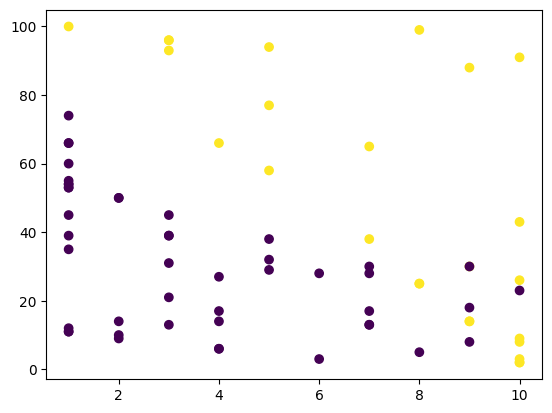

In [220]:
plt.scatter(df['form'],df['runs'],c = df['score_100'])

In [221]:
oversample = SMOTE()
X_df,y_df = oversample.fit_resample(df[['form','runs']],df['score_100'])


In [222]:
X_df.head()

,form,runs
0,6,28
1,9,18
2,2,9
3,1,55
4,4,17


In [223]:
y_df.head()

0    0
1    0
2    0
3    0
4    0
Name: score_100, dtype: int64

In [224]:
# combine 
combine_df = pd.concat([X_df,y_df],axis=1)
combine_df.head()

,form,runs,score_100
0,6,28,0
1,9,18,0
2,2,9,0
3,1,55,0
4,4,17,0


In [225]:
combine_df.shape

(92, 3)

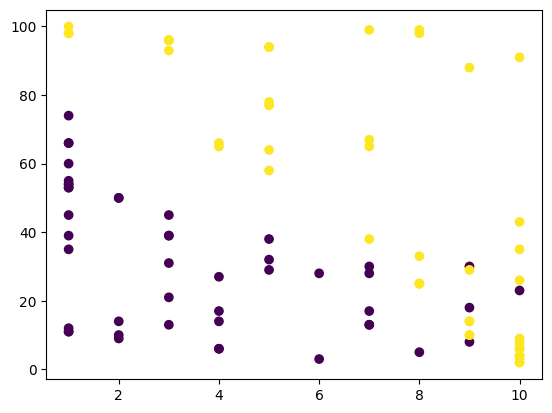

In [227]:
plt.scatter(combine_df['form'],combine_df['runs'],c=combine_df['score_100'])
plt.show()

In [232]:
import seaborn as sns

In [238]:
titanic_df = sns.load_dataset('titanic')

In [240]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [250]:
titanic_df.iloc[:,1:]

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [252]:
titanic_df.dropna(inplace=True)

titanic

In [258]:
titanic_df = titanic_df.select_dtypes(include=['int','float'])

In [259]:
titanic_df

,survived,pclass,age,sibsp,parch,fare
1,1,1,38.0,1,0,71.2833
3,1,1,35.0,1,0,53.1000
6,0,1,54.0,0,0,51.8625
10,1,3,4.0,1,1,16.7000
11,1,1,58.0,0,0,26.5500
...,...,...,...,...,...,...
871,1,1,47.0,1,1,52.5542
872,0,1,33.0,0,0,5.0000
879,1,1,56.0,0,1,83.1583
887,1,1,19.0,0,0,30.0000


In [261]:
titanic_df.shape

(182, 6)

In [267]:
titanic_df['survived'].value_counts()

survived
1    123
0     59
Name: count, dtype: int64

### Oversampling with Smote on titanic data

In [260]:
oversample = SMOTE()
X_df, y_df = oversample.fit_resample(titanic_df.iloc[:,1:],titanic_df['survived'])

In [262]:
X_df.shape,y_df.shape

((246, 5), (246,))

In [264]:
titanic_df_combine = pd.concat([X_df,y_df],axis=1)

In [265]:
titanic_df_combine.head()

,pclass,age,sibsp,parch,fare,survived
0,1,38.0,1,0,71.2833,1
1,1,35.0,1,0,53.1000,1
2,1,54.0,0,0,51.8625,0
3,3,4.0,1,1,16.7000,1
4,1,58.0,0,0,26.5500,1


In [266]:
titanic_df_combine['survived'].value_counts()

survived
1    123
0    123
Name: count, dtype: int64

### **Problem and Solution for Classic Smote**

* classic SMOTE doesn’t work properly with categorical data — but there are SMOTE variants that do 👍
* SMOTE creates new samples by interpolating between feature values.
- That works fine for numeric data:

2.3 → 2.7 → 3.1 ✔️

But for `categorical data`, interpolation makes no sense:

“red” ↔ “blue” → “purple”? ❌

### `Solution`
`SMOTE-NC` (most common fix)

Designed for mixed data (**Numerical + Categorical**)

Treats:

`numerical features` → interpolation

`categorical features` → mode (most frequent category among neighbors)